# Marketing Analytics: Customer Segmentation
**Level 1 - Project 2**

**Objective:** Segment customers using K-Means Clustering on marketing data.



In [1]:
# Install dependencies
!pip install numpy pandas matplotlib seaborn scikit-learn scipy --quiet

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
print('✅ Libraries imported!')

✅ Libraries imported!


## Load Dataset

In [11]:
#Reading the data
df = pd.read_excel("iFood.xlsx")

#Taking a look at the top 5 rows of the data
df.head()

,Index,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmpOverall,Complain,Age,Customer_Days,marital_status,education
0,1001,58138,0,0,58,635,88,546,172,88,...,0,0,0,0,0,0,63,2822,Single,Graduation
1,1002,46344,1,1,38,11,1,6,2,1,...,0,0,0,0,0,0,66,2272,Single,Graduation
2,1003,71613,0,0,26,426,49,127,111,21,...,0,0,0,0,0,0,55,2471,Together,Graduation
3,1004,26646,1,0,26,11,4,20,10,3,...,0,0,0,0,0,0,36,2298,Together,Graduation
4,1005,58293,1,0,94,173,43,118,46,27,...,0,0,0,0,0,0,39,2320,Married,PHD


## Data Exploration

In [12]:
df.info()
print('\nMissing values:')
print(df.isnull().sum()[df.isnull().sum()>0])
print(f'\nDuplicates: {df.duplicated().sum()}')
df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Index                2205 non-null   int64 
 1   Income               2205 non-null   int64 
 2   Kidhome              2205 non-null   int64 
 3   Teenhome             2205 non-null   int64 
 4   Recency              2205 non-null   int64 
 5   MntWines             2205 non-null   int64 
 6   MntFruits            2205 non-null   int64 
 7   MntMeatProducts      2205 non-null   int64 
 8   MntFishProducts      2205 non-null   int64 
 9   MntSweetProducts     2205 non-null   int64 
 10  MntRegularProds      2205 non-null   int64 
 11  MntGoldProds         2205 non-null   int64 
 12  MntTotal             2205 non-null   int64 
 13  NumDealsPurchases    2205 non-null   int64 
 14  NumWebPurchases      2205 non-null   int64 
 15  NumCatalogPurchases  2205 non-null   int64 
 16  NumSto

,count,mean,std,min,25%,50%,75%,max
Index,2205.0,2103.000000,636.672993,1001.0,1552.0,2103.0,2654.0,3205.0
Income,2205.0,51622.094785,20713.063826,1730.0,35196.0,51287.0,68281.0,113734.0
Kidhome,2205.0,0.442177,0.537132,0.0,0.0,0.0,1.0,2.0
Teenhome,2205.0,0.506576,0.544380,0.0,0.0,0.0,1.0,2.0
Recency,2205.0,49.009070,28.932111,0.0,24.0,49.0,74.0,99.0
MntWines,2205.0,306.164626,337.493839,0.0,24.0,178.0,507.0,1493.0
MntFruits,2205.0,26.403175,39.784484,0.0,2.0,8.0,33.0,199.0
MntMeatProducts,2205.0,165.312018,217.784507,0.0,16.0,68.0,232.0,1725.0
MntFishProducts,2205.0,37.756463,54.824635,0.0,3.0,12.0,50.0,259.0
MntSweetProducts,2205.0,27.128345,41.130468,0.0,1.0,8.0,34.0,262.0


## Data Cleaning & Feature Engineering

In [13]:
# Fill missing numerical values with median
for col in df.select_dtypes(include=[np.number]).columns:
    df[col].fillna(df[col].median(), inplace=True)
df.dropna(inplace=True)

# Feature Engineering
if 'Year_Birth' in df.columns: df['Age'] = 2024 - df['Year_Birth']
spending = [c for c in df.columns if c.startswith('Mnt')]
if spending: df['Total_Spending'] = df[spending].sum(axis=1)
camps = [c for c in df.columns if 'AcceptedCmp' in c]
if camps: df['Total_Campaigns'] = df[camps].sum(axis=1)
purchases = [c for c in df.columns if 'Num' in c and 'Purchases' in c]
if purchases: df['Total_Purchases'] = df[purchases].sum(axis=1)
kids = [c for c in df.columns if 'Kid' in c or 'Teen' in c]
if kids: df['Total_Children'] = df[kids].sum(axis=1)
print(f'Shape after engineering: {df.shape}')

Shape after engineering: (2205, 33)


## EDA

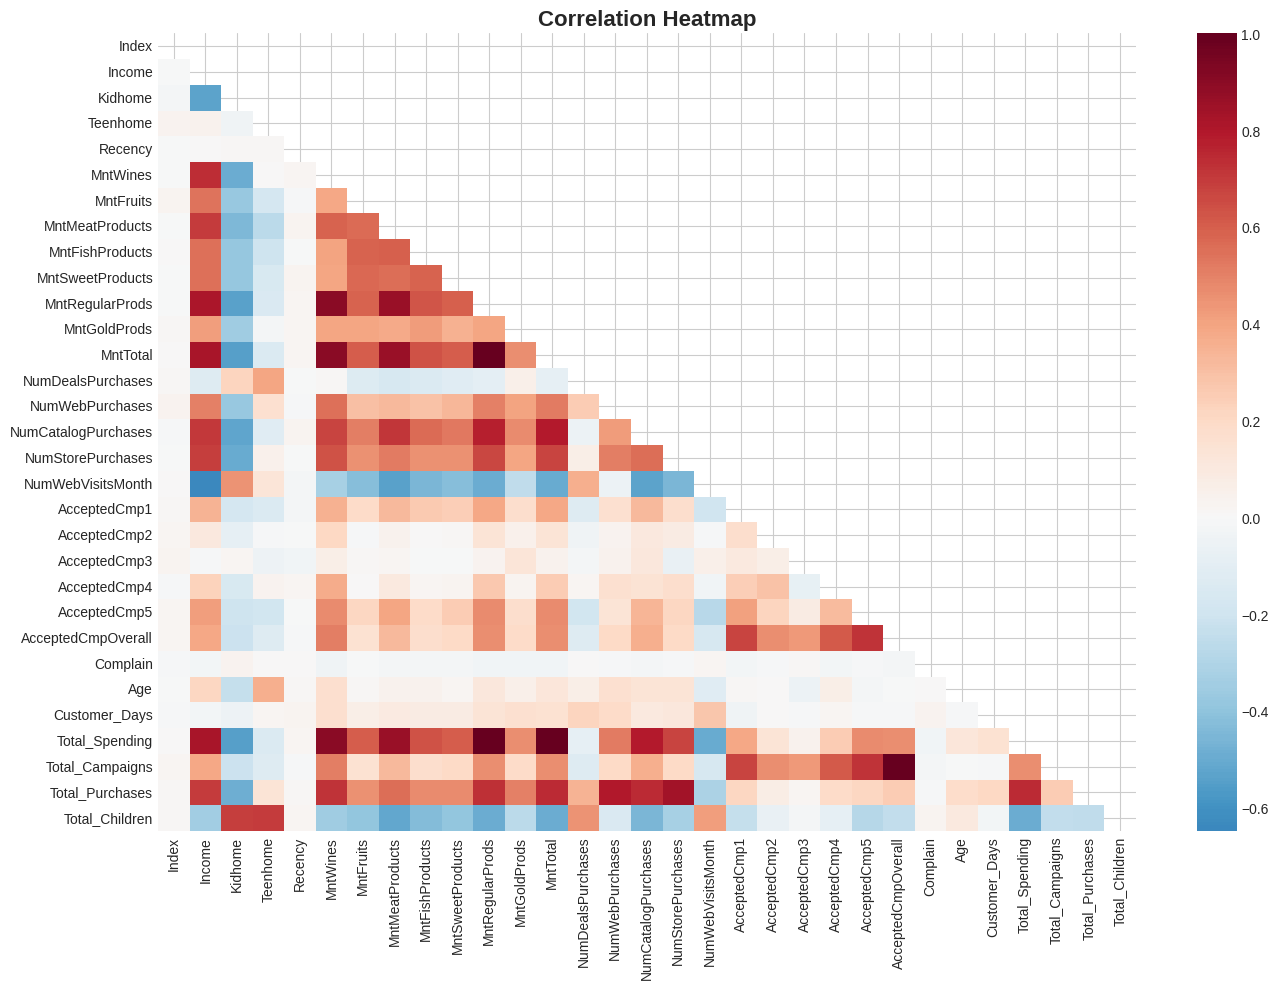

In [14]:
# Correlation heatmap
plt.figure(figsize=(14,10))
corr = df.select_dtypes(include=[np.number]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, fmt='.1f')
plt.title('Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

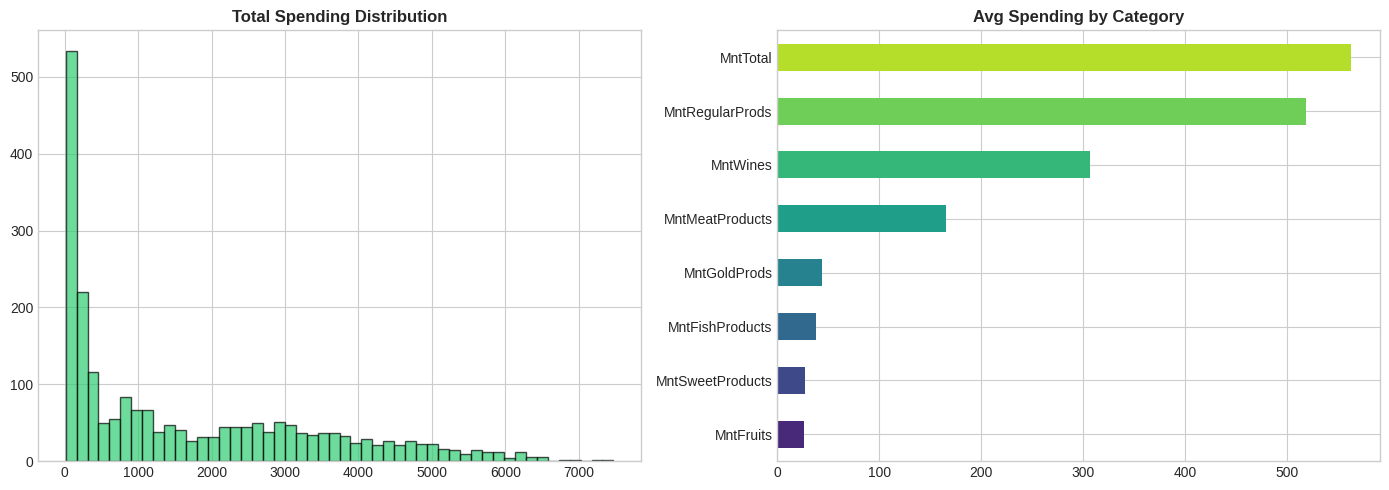

In [15]:
# Distribution of spending
if 'Total_Spending' in df.columns:
    fig,axes=plt.subplots(1,2,figsize=(14,5))
    axes[0].hist(df['Total_Spending'],bins=50,edgecolor='black',alpha=0.7,color='#2ecc71')
    axes[0].set_title('Total Spending Distribution',fontweight='bold')
    if spending:
        df[spending].mean().sort_values().plot(kind='barh',ax=axes[1],color=sns.color_palette('viridis',len(spending)))
        axes[1].set_title('Avg Spending by Category',fontweight='bold')
    plt.tight_layout(); plt.show()

##  Prepare for Clustering

In [16]:
# Select numerical features, drop IDs
drop = [c for c in df.columns if 'ID' in c.upper()] + df.select_dtypes(include=['object','datetime64']).columns.tolist()
features = [c for c in df.columns if c not in drop]
X = df[features].copy()
# Clip outliers
for c in X.columns: X[c] = X[c].clip(X[c].quantile(0.05), X[c].quantile(0.95))
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f'Feature matrix: {X_scaled.shape}')

Feature matrix: (2205, 30)


## PCA

In [17]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(f'Variance explained: {pca.explained_variance_ratio_.sum():.2%}')

Variance explained: 49.73%


## K-Means Clustering

K=2: Silhouette=0.3088
K=3: Silhouette=0.2762
K=4: Silhouette=0.2197
K=5: Silhouette=0.1479
K=6: Silhouette=0.2199
K=7: Silhouette=0.1417
K=8: Silhouette=0.1513
K=9: Silhouette=0.1548
K=10: Silhouette=0.1584


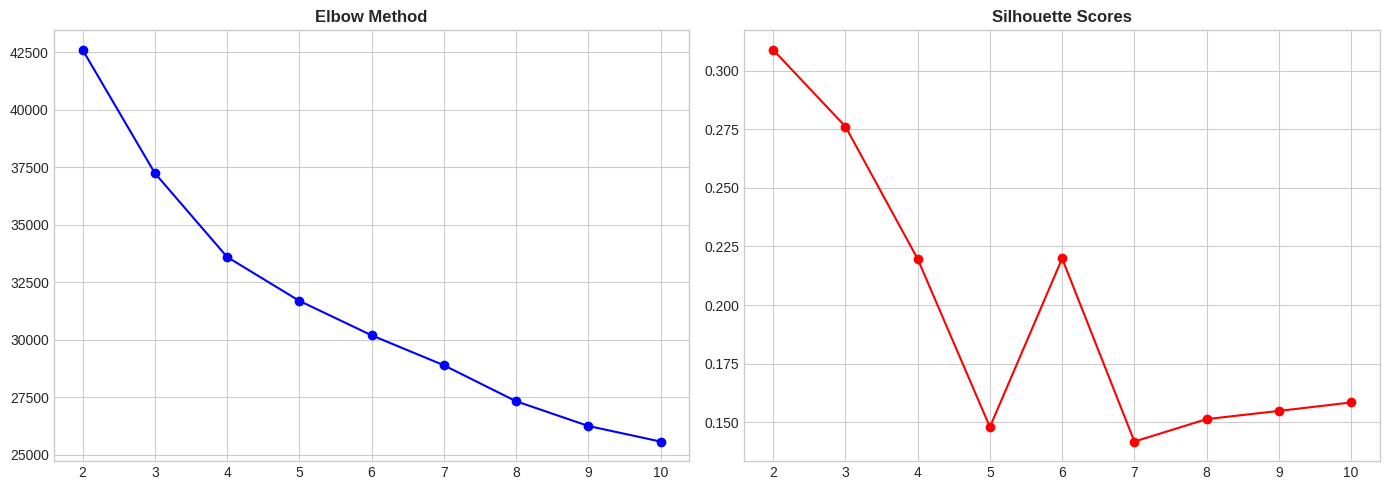


 Optimal K: 2


In [19]:
# Elbow + Silhouette
inertias, sil_scores = [], []
K = range(2, 11)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    print(f'K={k}: Silhouette={sil_scores[-1]:.4f}')

fig,axes=plt.subplots(1,2,figsize=(14,5))
axes[0].plot(K,inertias,'bo-'); axes[0].set_title('Elbow Method',fontweight='bold')
axes[1].plot(K,sil_scores,'ro-'); axes[1].set_title('Silhouette Scores',fontweight='bold')
plt.tight_layout(); plt.show()
optimal_k = list(K)[np.argmax(sil_scores)]
print(f'\n Optimal K: {optimal_k}')

In [20]:
# Final model
final_k = min(optimal_k, 5)
km_final = KMeans(n_clusters=final_k, random_state=42, n_init=10)
df['Cluster'] = km_final.fit_predict(X_scaled)
print(f'Silhouette: {silhouette_score(X_scaled, df["Cluster"]):.4f}')
print(df['Cluster'].value_counts().sort_index())

Silhouette: 0.3088
Cluster
0     883
1    1322
Name: count, dtype: int64


## Cluster Visualization

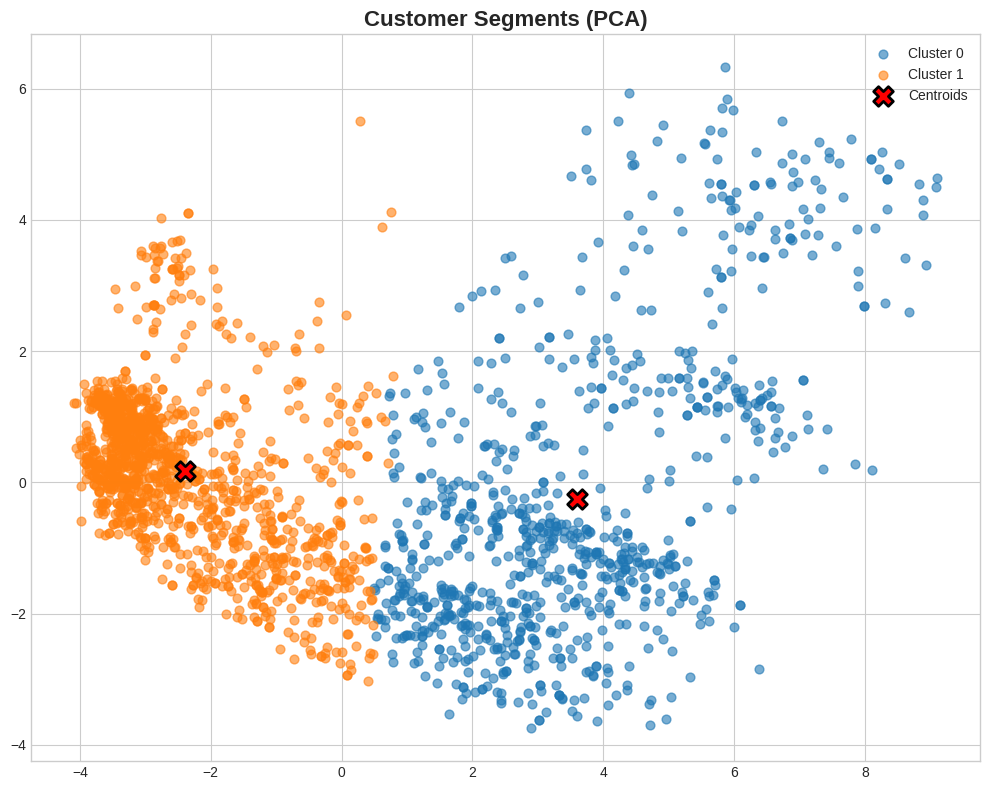

In [21]:
fig,ax=plt.subplots(figsize=(10,8))
for i in range(final_k):
    mask=df['Cluster']==i
    ax.scatter(X_pca[mask,0],X_pca[mask,1],label=f'Cluster {i}',alpha=0.6,s=40)
centroids=pca.transform(km_final.cluster_centers_)
ax.scatter(centroids[:,0],centroids[:,1],c='red',marker='X',s=200,edgecolors='black',linewidth=2,label='Centroids')
ax.set_title('Customer Segments (PCA)',fontsize=16,fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()

In [22]:
# Cluster profiles
profile = df.groupby('Cluster')[features].mean()
print('\nCluster Profiles (Mean):')
profile.T


Cluster Profiles (Mean):


Cluster,0,1
Index,2102.841450,2103.105900
Income,71264.519819,38502.381241
Teenhome,0.426954,0.559758
Recency,49.462061,48.706505
MntWines,620.596829,96.146747
MntFruits,55.634202,6.878971
MntMeatProducts,357.457531,36.972769
MntFishProducts,79.194790,10.078669
MntSweetProducts,56.861835,7.268533
MntRegularProds,1094.732729,133.964448


## Summary

In [23]:
print('='*60)
print('CUSTOMER SEGMENTATION SUMMARY')
print('='*60)
print(f'Clusters: {final_k}')
print(f'Silhouette: {silhouette_score(X_scaled, df["Cluster"]):.4f}')
for c in range(final_k):
    n=(df['Cluster']==c).sum()
    print(f'  Cluster {c}: {n} customers ({n/len(df)*100:.1f}%)')

CUSTOMER SEGMENTATION SUMMARY
Clusters: 2
Silhouette: 0.3088
  Cluster 0: 883 customers (40.0%)
  Cluster 1: 1322 customers (60.0%)
